In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

Shape Input: 8 features
Epoch 1/20
363/363 [==============================] - 0s 854us/step - loss: 1.3400 - mae: 0.8163 - val_loss: 0.5904 - val_mae: 0.5574
Epoch 2/20
363/363 [==============================] - 0s 616us/step - loss: 0.5034 - mae: 0.5175 - val_loss: 0.4757 - val_mae: 0.4749
Epoch 3/20
363/363 [==============================] - 0s 601us/step - loss: 0.4123 - mae: 0.4683 - val_loss: 0.7078 - val_mae: 0.4606
Epoch 4/20
363/363 [==============================] - 0s 607us/step - loss: 0.3858 - mae: 0.4479 - val_loss: 0.4054 - val_mae: 0.4391
Epoch 5/20
363/363 [==============================] - 0s 615us/step - loss: 0.3685 - mae: 0.4343 - val_loss: 0.9747 - val_mae: 0.4451
Epoch 6/20
363/363 [==============================] - 0s 609us/step - loss: 0.3636 - mae: 0.4286 - val_loss: 1.4573 - val_mae: 0.4345
Epoch 7/20
363/363 [==============================] - 0s 829us/step - loss: 0.3618 - mae: 0.4230 - val_loss: 2.1575 - val_mae: 0.4407
Epoch 8/20
363/363 [==================

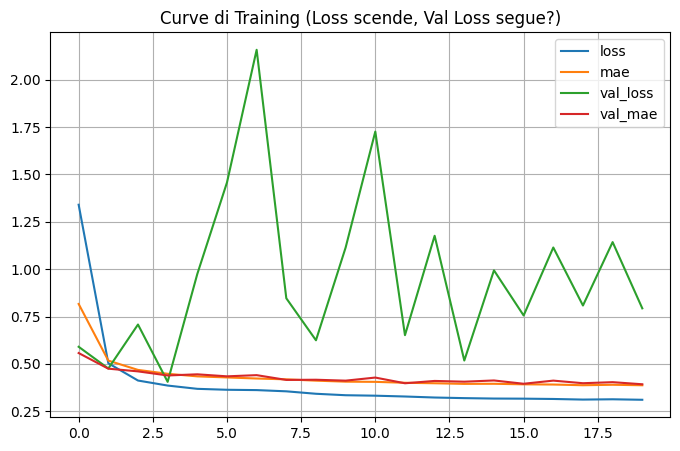

In [6]:
# --- 1. PREPARAZIONE DATI ---
# Carichiamo il dataset
housing = fetch_california_housing()
X, y = housing.data, housing.target

# Split Train/Test (Fondamentale per valutare l'overfitting)
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full, random_state=42)

# !!! PASSAGGIO CRUCIALE !!!
# A differenza dei Decision Tree, le Reti Neurali richiedono input scalati.
# Se non lo fate, i gradienti esploderanno o il training sarà lentissimo.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)

print(f"Shape Input: {X_train.shape[1]} features") # Dovrebbe essere 8

# --- 2. COSTRUZIONE MODELLO (Architecture Design) ---
model_reg = models.Sequential([
    # Input Layer implicito nella definizione del primo Dense
    # Struttura a "Imbuto": Partiamo larghi e stringiamo
    layers.Dense(32, activation="relu", input_shape=X_train.shape[1:]),
    
    # Secondo strato hidden per catturare non-linearità complesse
    layers.Dense(16, activation="relu"),
    
    # OUTPUT LAYER (Regressione)
    # 1 solo neurone (prezzo). 
    # Nessuna attivazione (può essere qualsiasi valore positivo).
    layers.Dense(1) 
])

# --- 3. COMPILAZIONE (Il cervello) ---
model_reg.compile(
    loss="mse",                # Mean Squared Error: standard per regressione
    optimizer="adam",          # Adam gestisce il learning rate da solo
    metrics=["mae"]            # Monitoriamo l'errore assoluto (più leggibile dell'MSE)
)

# --- 4. TRAINING (Il sudore) ---
history = model_reg.fit(
    X_train, y_train,
    epochs=20,                 # Proviamo 20 giri completi
    batch_size=32,             # Aggiorniamo i pesi ogni 32 case
    validation_data=(X_valid, y_valid), # Controllo in tempo reale
    verbose=1
)

# --- 5. ANALISI DEI RISULTATI ---
# Valutazione finale sul Test Set (dati mai visti)
mse_test, mae_test = model_reg.evaluate(X_test, y_test)
print(f"\nErrore Medio Assoluto sul Test Set: {mae_test:.2f} (in centinaia di migliaia di $)")

# Visualizzazione della curva di apprendimento
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.title("Curve di Training (Loss scende, Val Loss segue?)")
plt.show()